c:\Users\kunal\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 3.1035680770874023


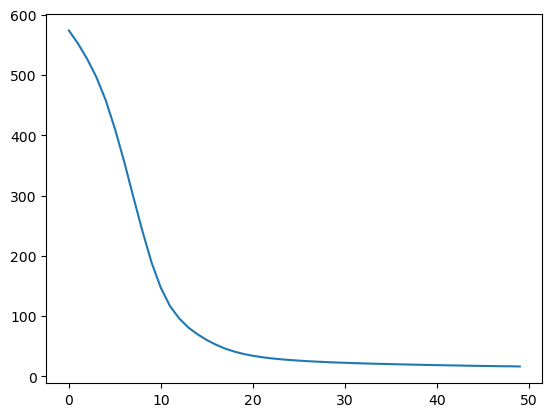

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

data = pd.read_csv("Boston_Housing.csv")
X = data.drop("MEDV", axis=1)
y = data["MEDV"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=50, verbose=0)

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("MAE:", mae)

plt.plot(history.history['loss'])
plt.show()


In [ ]:
# ==============================
# Step 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping



# ==============================
# Step 2: Load Dataset
# ==============================
df = pd.read_csv("Boston_Housing.csv")

# Remove unwanted quotes from column names
df.columns = df.columns.str.replace('"', '')

# Display dataset
print(df.head())



# ==============================
# Step 3: Split Features & Target
# ==============================
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)



# ==============================
# Step 4: Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# Step 5: Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




# ==============================
# Step 6: Build Deep Neural Network
# ==============================
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    
    Dense(1, activation='linear')   # Output layer (Regression)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display model summary
model.summary()



# ==============================
# Step 7: Train Model
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)



# ==============================
# Step 8: Evaluate Model
# ==============================
loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss (MSE):", loss)
print("Test MAE:", mae)




# ==============================
# Step 9: Predictions
# ==============================
y_pred = model.predict(X_test)

print("\nActual vs Predicted (First 5 values):")
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")





# ==============================
# Step 10: Plot Training Graphs
# ==============================
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.title("MAE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.show()


ModuleNotFoundError: No module named 'tensorflow'